In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os, sys
os.environ["FOLPS_BACKEND"] = "numpy"  #'numpy' or 'jax'
sys.path.append('../folps')
import folps as FOLPS
os.system('pwd');

/global/homes/p/prakharb/.local/lib/python3.12/site-packages/triumvirate/winconv.py:81: UserWarning: The `triumvirate.winconv` module is currently experimental. Its behaviour has not been fully tested and may change in the future.
  warnings.warn(


✅ Using NumPy with CPU.
/global/u1/p/prakharb/FOLPS_JAX/notebooks


sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: ml: line 1: syntax error: unexpected end of file
sh: error importing function definition for `ml'


In [2]:
model = 'FOLPSD'  ## it can be 'FOLPSD', 'TNS' or 'EFT'.  default is 'EFT' 
damping = 'lor'  ## it can be 'lor' or 'exp' or damping = None.
use_TNS_model=False ## True for TNS, default is False

if model == 'TNS':
    use_TNS_model=True 
    if damping == None:
        damping = 'lor'
if model == 'EFT':
    damping = None 

#### Inputs

Fix *cosmological* and *nuisance parameters*. Upload the corresponding linear power spectrum. You can also compute it using an Einstein-Boltzmann code like **CAMB**, **CLASS**, etc. 

Cosmological parameters:

Define a dictionary with the cosmological parameters: kwargs

In [3]:
#CMASS NGC cosmology

m_nu = 0.4    #sum of the neutrino masses in eV
omega_b = 0.02242;        #baryons
omega_cdm = 0.117;       #CDM
h = 0.67;                 #h = H0/100
z_ev = 0.57;              #evaluation redshift


omega_ncdm = m_nu/93.14; 
Omega_m = (omega_cdm+omega_b+omega_ncdm)/h**2
fnu = omega_ncdm/(omega_cdm+omega_b+omega_ncdm)
# CosmoParams = [z_pk, omega_b, omega_cdm, omega_ncdm, h]  //Deprecated. Now folps uses kwargs

kwargs = {'z': z_ev,
          'h': h,
          'Omega_m': Omega_m,
          # 'f0': np.float64(0.6880638641959066),  #if not provided, the code computes it
          'fnu': fnu,
         }

f0=FOLPS.get_f0(z_ev,kwargs['Omega_m']) 
print(kwargs['Omega_m'],f0)   

0.3201483855293351 0.7866042388430216


Linear power spectrum at redshift z_ev, in Mpc/h units

In [4]:
# inputpkT = np.loadtxt('pk_linear_simtocmass.txt', unpack = True)
# # Fallback: read precomputed k, pk from the repository file (do not create a cosmo object)
data_path = 'pk_linear_simtocmass.txt'
k_arr, pk_arr = np.loadtxt(data_path, unpack=True)
classy = {'k': k_arr, 'pk': pk_arr} # Provide k and pk only in Mpc/h units

Nuisance parameters for the linear power spectrum:

Define a vector with the nuisances parameters, NuisanParams = [b1, b2, bs2, b3nl, alpha0, alpha2, alpha4, ctilde, alphashot0, alphashot2, PshotP]

In [5]:
#bias parameters   
# if bias_scheme='folps'   then b2=b2_mcdonald, bs=bs_mcdonald, b3=b3nl_mcdonald   (DEFAULT)
# if bias_scheme='classpt' then b2=b2_assassi,  bs=bG2_assassi, b3=bGamma3_assassi

bias_scheme='folps'
b1 = 1.9;                 
b2 = 8/21*(b1-1)
bs = -4/7*(b1-1)      
b3 = 32/315*(b1 - 1);  

#EFT parameters
alpha0, alpha2, alpha4 = 0,0,0    # PEFT(k) = (alpha0 + alpha2*mu^2+ alpha4*mu^4)  k^2 Plin(k)
ctilde = 0               #NLO counterterm
X_FoG = 0  # uses a Lorentzian Damping 1/(1+x^2), with x = X_FoG f sigma_v mu. 

#Stochatics parameters
# Noise is Pshot = PshotP * ( alphashot0 + alphashot2*(k*mu)**2 )
alphashot0 = 0;          
alphashot2 = 0;            
PshotP = 1/1e4    # =1/barn.  Poissonian shot noise
NuisanParams = [b1, b2, bs, b3, alpha0, alpha2, alpha4, ctilde, alphashot0, alphashot2, PshotP,X_FoG]


# Computation of $M$ matrices 
Do not depend on the cosmology, so they are computed only the first time the code is called

In [6]:
matrix = FOLPS.MatrixCalculator(A_full=True,use_TNS_model=use_TNS_model) # TNS model: use_TNS_model=True
mmatrices = matrix.get_mmatrices()

Loading matrices from matrices_nfftlog128_Afull-True_use_TNS-False.npy


### Alcock-Paczyński effect 

In [7]:
Omfid = -1  # Fiducial cosmology. for AP set > 0    
qpar, qperp = FOLPS.qpar_qperp(Omega_fid=-1, Omega_m=kwargs['Omega_m'], z_pk=kwargs['z'], cosmo=None)    
              # For LCDM. Introduce yours for different cosmo.
qpar,qperp # gives 1,1 if Omega_fid<=0 or z_ev=0

(1, 1)

# Power spectrum

In [8]:
# output k_ev
k_ev = np.logspace(np.log10(0.01), np.log10(0.3), num = 40) # array of k_ev in [h/Mpc]

In [9]:
%%time

nonlinear = FOLPS.NonLinearPowerSpectrumCalculator(mmatrices=mmatrices,kernels='fk',**kwargs)
## kernels can be 'fk' or 'EdS'

table, table_nonwiggles = nonlinear.calculate_loop_table(k=classy['k'], pklin=classy['pk'],cosmo=None, **kwargs)
## cosmo is the CLASS engine

multipoles = FOLPS.RSDMultipolesPowerSpectrumCalculator(model=model) 

pkl0, pkl2, pkl4  = multipoles.get_rsd_pkell(kobs=k_ev, qpar=qpar, qper=qperp, pars=NuisanParams,
                                       table=table, table_now=table_nonwiggles,
                                       bias_scheme='folps', damping='lor'
                                       )

# can change the bias scheme to bias_scheme='classpt' to use Assassi et al biases (1402.5916,2004.10607)

CPU times: user 255 ms, sys: 15.6 ms, total: 271 ms
Wall time: 66.8 ms


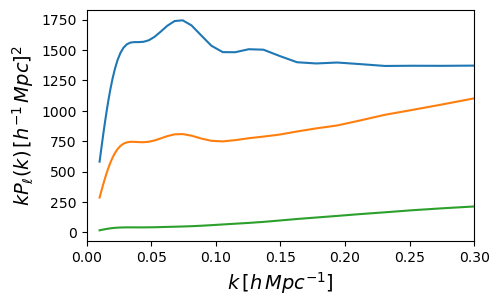

In [10]:
kh=k_ev

fig, axs = plt.subplots(figsize=(5,3))
axs.set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize =  14)
axs.set_ylabel(r'$k P_{\ell}(k) \, [h^{-1} \,  Mpc]^2$', fontsize =  14)

axs.plot(kh, kh * pkl0, label=r'$\ell = 0$')
axs.plot(kh, kh * pkl2, label=r'$\ell = 2$')
axs.plot(kh, kh * pkl4, label=r'$\ell = 4$')

axs.set_xlim([0, 0.3])
plt.show()


# Bispectrum

In [11]:
#pars for Bispectrum
Pshot = 0; # This would be the same as PshopP*alphashot0 if the bispectrum were computed up to 1loop (I think!)
Bshot = 0
c1=0
c2=0
X_FoG_bk=1

bpars = [b1, b2, bs, c1, c2, Bshot, Pshot, X_FoG_bk]

linear=nonlinear.get_linear(classy['k'], classy['pk'], pknow=None, cosmo=None, **kwargs)   
#linear['k'],linear['f0'],linear['f_k'],linear['pk_l'],linear['pk_l_NW']

k_pkl_pklnw = np.array([linear['k'], linear['pk_l'],linear['pk_l_NW']])

## Sugiyama basis

In [12]:
k_ev = np.linspace(0.01,0.2, num = 40) 
k1k2T =np.vstack([k_ev,k_ev]).T   # List of pairs of k. (B=B(k1,k2))


In [13]:
%%time
bispectrum = FOLPS.BispectrumCalculator(model = model)

B000, B110, B220, B202, B022, B112 = bispectrum.Sugiyama_Bell(
        f=f0,  
        bpars=bpars,
        k_pkl_pklnw=k_pkl_pklnw, 
        k1k2pairs=k1k2T, qpar=1, qper=1, precision=[8,10,10], 
        damping='lor',
        multipoles = ['B000', 'B110', 'B220', 'B202', 'B022', 'B112'],
        renormalize = True,
        interpolation_method='linear',
        bias_scheme='folps'
    )


CPU times: user 3.82 ms, sys: 1.11 ms, total: 4.93 ms
Wall time: 4.43 ms


In [14]:
k_pkl_pklnw = np.array([linear['k'], linear['pk_l'],linear['pk_l_NW']])

Text(0.5, 1.0, 'B_l1l2L * H_l1l2L')

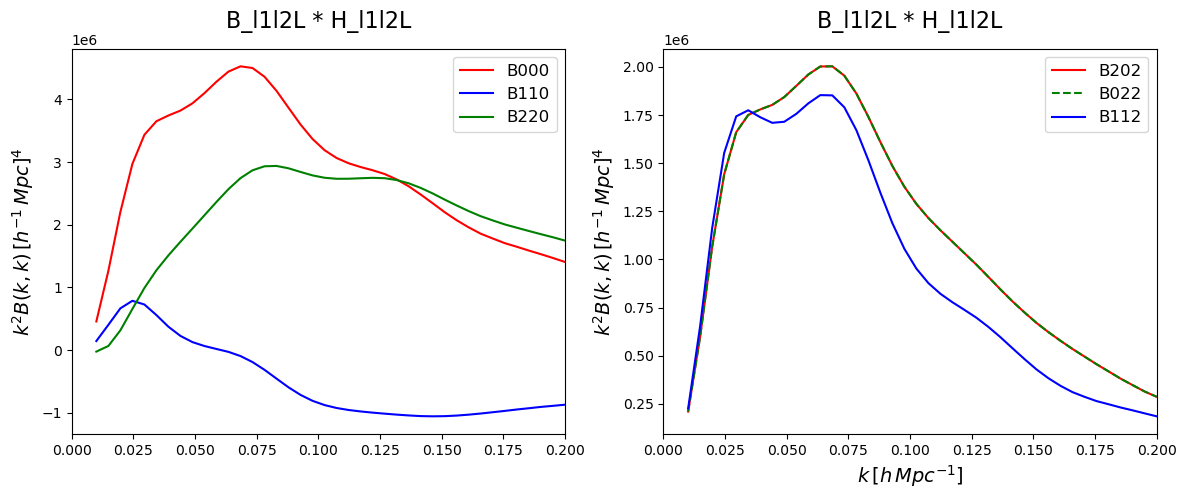

In [15]:
xmax=0.2

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].set_ylabel(r'$k^2 B(k,k) \, [h^{-1} \,  Mpc]^4$', fontsize=14)
axs[0].plot(k_ev, k_ev**2 * B000, label=r'B000', ls='-', color='red')
axs[0].plot(k_ev, k_ev**2 * B110, label=r'B110', ls='-', color='blue')
axs[0].plot(k_ev, k_ev**2 * B220, label=r'B220', ls='-', color='green')
axs[0].set_xlim([0, xmax])
axs[0].legend(fontsize=12, loc='best')
axs[0].set_title('B_l1l2L * H_l1l2L', fontsize=16, pad=15)

axs[1].set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize=14)
axs[1].set_ylabel(r'$k^2 B(k,k) \, [h^{-1} \,  Mpc]^4$', fontsize=14)
axs[1].plot(k_ev, k_ev**2 * B202, label=r'B202', ls='-', color='red')
axs[1].plot(k_ev, k_ev**2 * B022, label=r'B022', ls='--', color='green')
axs[1].plot(k_ev, k_ev**2 * B112, label=r"B112", ls='-', color='blue')

axs[1].set_xlim([0, xmax])
axs[1].legend(fontsize=12, loc='best')
axs[1].set_title('B_l1l2L * H_l1l2L', fontsize=16, pad=15)

### Class BispectrumCalculator_fk

For introducing fk in the bispectrum. 

Perhaps not necessary for large error bars

different input:

k_pkl_pklnw_fk = np.array([k, pkl, pklnw,fk, A,Ap, R1,R1p])

LCDM: A,Ap, R1,R1p = 1,0,1,1

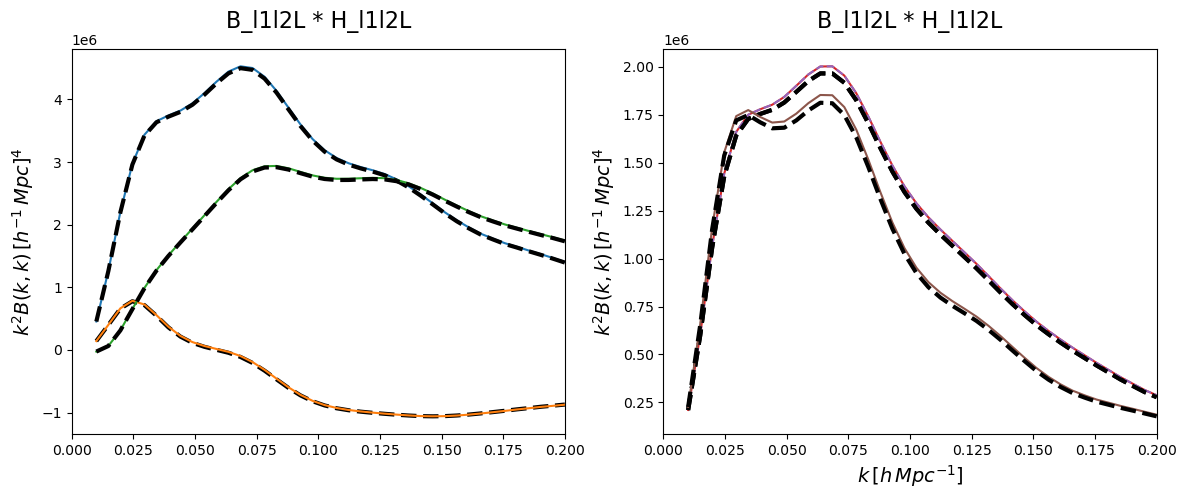

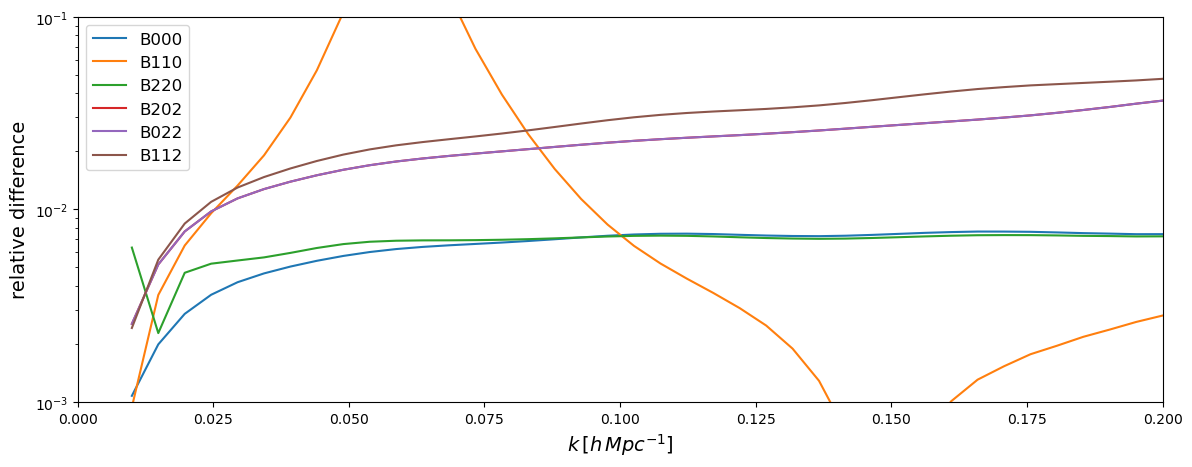

In [17]:
ll=len(linear['k'])
A,Ap, R1,R1p = np.array([1]*ll), np.array([0]*ll), np.array([1]*ll), np.array([1]*ll)
k_pkl_pklnw_fk = np.array([linear['k'], linear['pk_l'],linear['pk_l_NW'],linear['f_k'],A,Ap, R1,R1p])
bispectrum_fk = FOLPS.BispectrumCalculator_fk(model = model)

B000_fk, B110_fk, B220_fk, B202_fk, B022_fk, B112_fk = bispectrum_fk.Sugiyama_Bell(
        f=f0,  
        bpars=bpars,
        k_pkl_pklnw_fk=k_pkl_pklnw_fk, 
        k1k2pairs=k1k2T, qpar=1, qper=1, precision=[8,10,10], 
        damping='lor',
        multipoles = ['B000', 'B110', 'B220', 'B202', 'B022', 'B112'],
        renormalize = True,
        interpolation_method='linear'
    )


xmax=0.2
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].set_ylabel(r'$k^2 B(k,k) \, [h^{-1} \,  Mpc]^4$', fontsize=14)
axs[0].plot(k_ev, k_ev**2 * B000, label=r'B000', ls='-', color='C0')
axs[0].plot(k_ev, k_ev**2 * B000_fk, label=r'B110', ls='--', color='k', lw=3)
axs[0].plot(k_ev, k_ev**2 * B110_fk, label=r'B110', ls='--', color='k', lw=3)
axs[0].plot(k_ev, k_ev**2 * B110, label=r'B110', ls='-', color='C1')
axs[0].plot(k_ev, k_ev**2 * B220, label=r'B220', ls='-', color='C2')
axs[0].plot(k_ev, k_ev**2 * B220_fk, label=r'B110', ls='--', color='k', lw=3)
axs[0].set_xlim([0, xmax])
# axs[0].legend(fontsize=12, loc='best')
axs[0].set_title('B_l1l2L * H_l1l2L', fontsize=16, pad=15)

axs[1].set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize=14)
axs[1].set_ylabel(r'$k^2 B(k,k) \, [h^{-1} \,  Mpc]^4$', fontsize=14)
axs[1].plot(k_ev, k_ev**2 * B202, label=r'B202', ls='-', color='C3')

axs[1].plot(k_ev, k_ev**2 * B202_fk, label=r'B202', ls='--', color='k', lw=3)
axs[1].plot(k_ev, k_ev**2 * B022, label=r'B022', ls='--', color='C4')
axs[1].plot(k_ev, k_ev**2 * B022_fk, label=r'B202', ls='--', color='k', lw=3)
axs[1].plot(k_ev, k_ev**2 * B112, label=r"B112", ls='-', color='C5')
axs[1].plot(k_ev, k_ev**2 * B112_fk, label=r"B112", ls='--', color='k', lw=3)

axs[1].set_xlim([0, xmax])
# axs[1].legend(fontsize=12, loc='best')
axs[1].set_title('B_l1l2L * H_l1l2L', fontsize=16, pad=15)

if kwargs['fnu']!=0:
    xmax=0.2
    fig, axs = plt.subplots(1, 1, figsize=(14, 5))

    axs.set_ylabel(r'relative difference', fontsize=14)
    axs.semilogy(k_ev, np.abs(1-B000/B000_fk), label=r'B000', ls='-')
    axs.semilogy(k_ev, np.abs(1-B110/B110_fk), label=r'B110', ls='-')
    axs.semilogy(k_ev, np.abs(1-B220/B220_fk), label=r'B220', ls='-')
    axs.set_xlim([0, xmax])
    # axs[0].legend(fontsize=12, loc='best')

    axs.set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize=14)

    axs.semilogy(k_ev, np.abs(1-B202/B202_fk), label=r'B202', ls='-')
    axs.semilogy(k_ev, np.abs(1-B022/B022_fk), label=r'B022', ls='-')
    axs.semilogy(k_ev, np.abs(1-B112/B112_fk), label=r"B112", ls='-')


    axs.set_xlim([0, xmax])
    axs.set_ylim([0.001, 0.1])
    axs.legend(fontsize=12, loc='best')

#### Run 2D multipoles


In [18]:
def reconstruct_symmetric(Btri, Nk):
    i, j = np.tril_indices(Nk)
    B = np.zeros((Nk, Nk))
    B[i, j] = Btri
    B[j, i] = Btri
    return B


def reconstruct_B202_B022(B202_tri, B022_tri, Nk):
    i, j = np.tril_indices(Nk)

    B202 = np.zeros((Nk, Nk))
    B022 = np.zeros((Nk, Nk))

    # Lower triangle (direct)
    B202[i, j] = B202_tri
    B022[i, j] = B022_tri

    # Upper triangle (cross-fill)
    B202[j, i] = B022_tri
    B022[j, i] = B202_tri

    return B202, B022

In [19]:
k_ev = np.linspace(0.01, 0.2, num=40)
Nk = len(k_ev)

# LOWER triangular indices (k1 >= k2)
i, j = np.tril_indices(Nk)

k1k2pairs = np.column_stack((k_ev[i], k_ev[j]))

In [20]:
%%time
Bk2D = bispectrum.Sugiyama_Bell(
        f=f0,  
        bpars=bpars,
        k_pkl_pklnw=k_pkl_pklnw, 
        k1k2pairs=k1k2pairs, qpar=1, qper=1, precision=[8,10,10], 
        damping='lor',
        multipoles = ['B000', 'B110', 'B220', 'B202', 'B022', 'B112'],
        renormalize = True,
        interpolation_method='linear'
    )

B000_2D, B110_2D, B220_2D, B202_2D, B022_2D, B112_2D = Bk2D

B000_grid = reconstruct_symmetric(B000_2D, Nk)
B110_grid = reconstruct_symmetric(B110_2D, Nk)
B220_grid = reconstruct_symmetric(B220_2D, Nk)
B112_grid = reconstruct_symmetric(B112_2D, Nk)

B202_grid, B022_grid = reconstruct_B202_B022(
    B202_2D, B022_2D, Nk
)

CPU times: user 97.1 ms, sys: 47 ms, total: 144 ms
Wall time: 184 ms


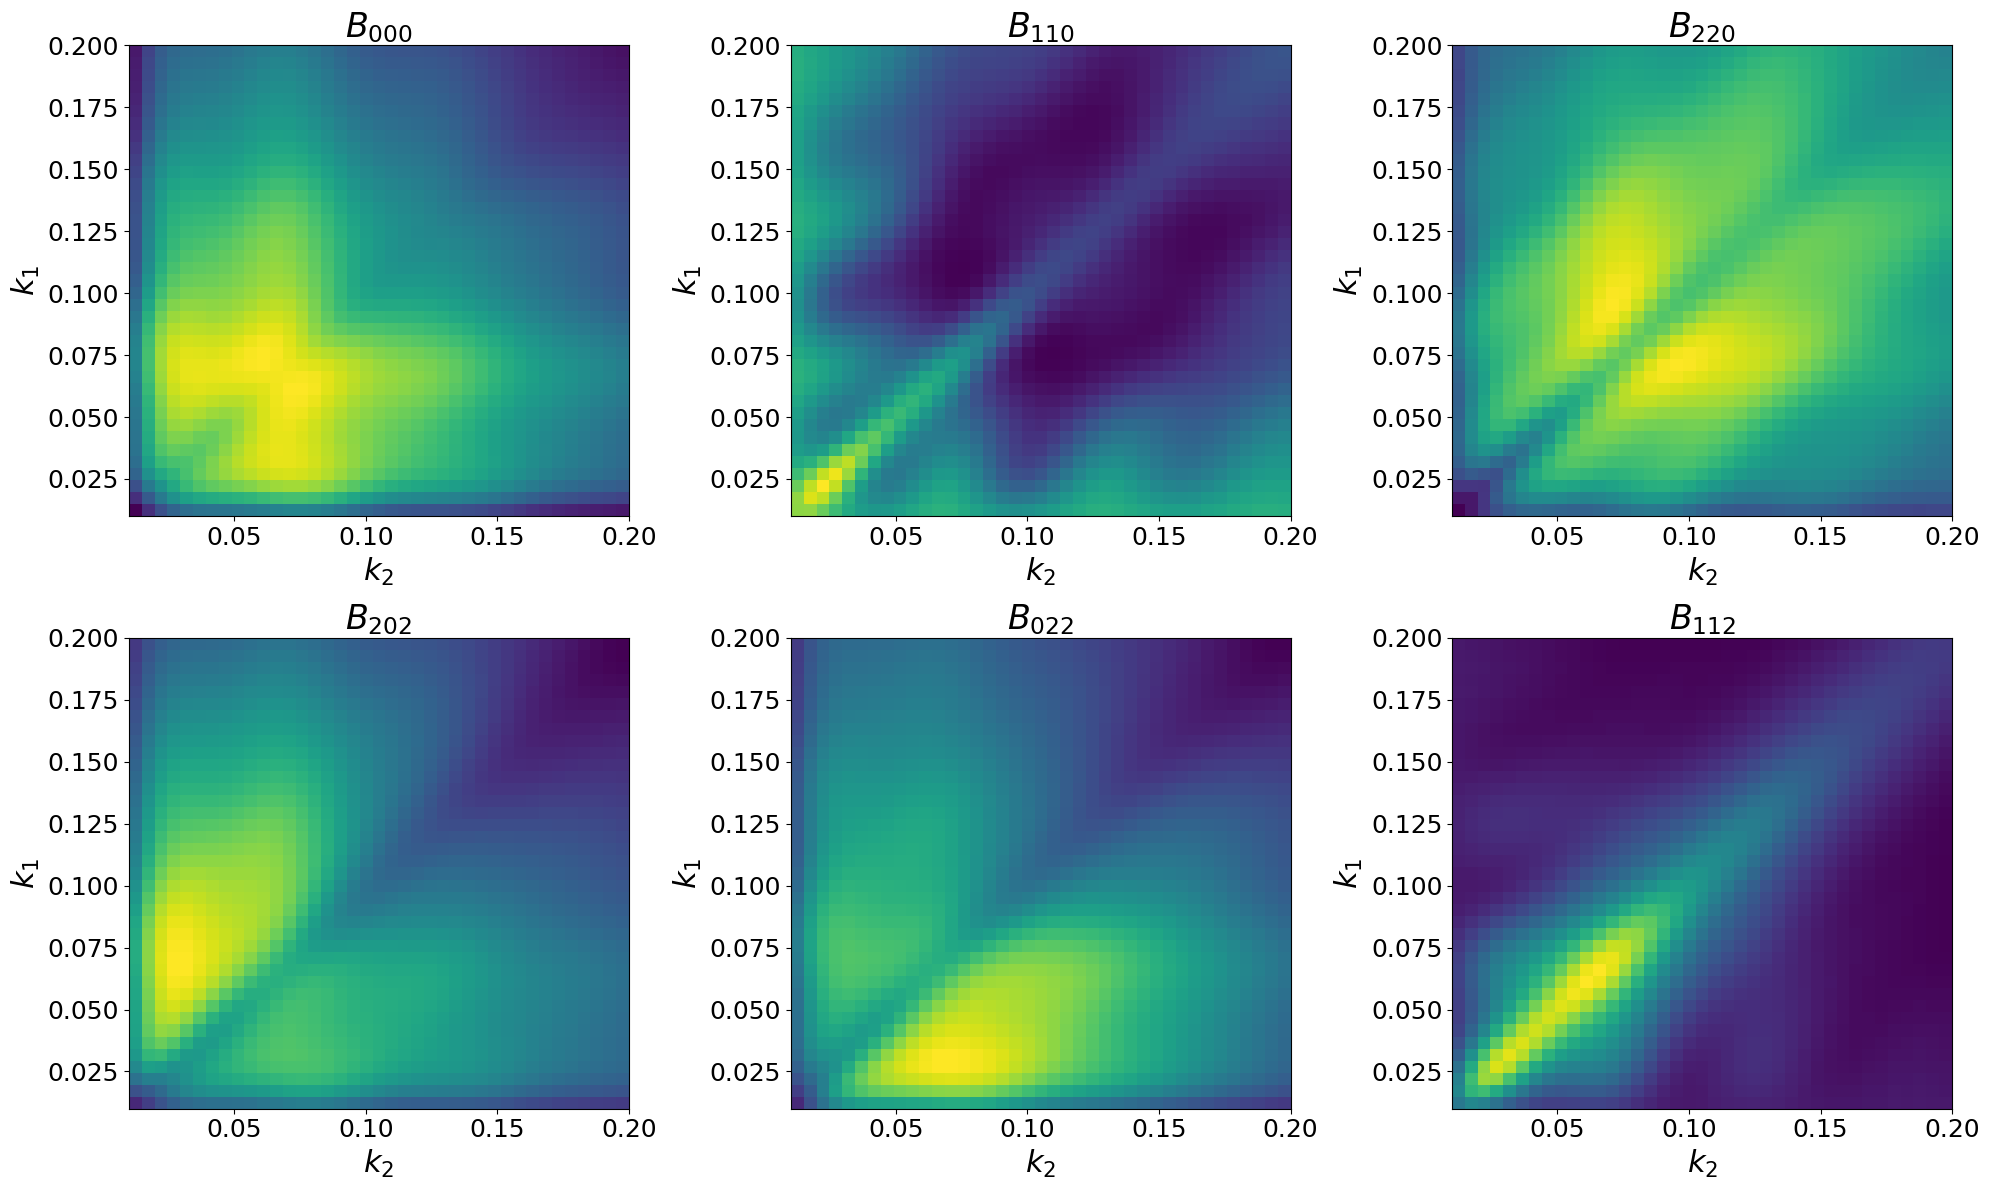

In [21]:
k1_vals = np.unique(k1k2pairs[:,0])
k2_vals = np.unique(k1k2pairs[:,1])

B000_scaled = B000_grid * k2_vals[:, None] * k1_vals[None, :]
B110_scaled = B110_grid * k2_vals[:, None] * k1_vals[None, :]
B220_scaled = B220_grid * k2_vals[:, None] * k1_vals[None, :]
B202_scaled = B202_grid * k2_vals[:, None] * k1_vals[None, :]
B022_scaled = B022_grid * k1_vals[:, None] * k2_vals[None, :]
B112_scaled = B112_grid * k2_vals[:, None] * k1_vals[None, :]

fig, axes = plt.subplots(2, 3, figsize=(20,12))

fs=24
fsk=22
fsl=18
showbar=False
# B000 imshow
im0 = axes[0,0].imshow(B000_scaled[1:,1:], 
                     origin='lower',
                     extent=[k2_vals.min(), k2_vals.max(), 
                             k1_vals.min(), k1_vals.max()],
                     aspect='auto')
axes[0,0].set_title(r"$B_{000}$", fontsize=fs)
axes[0,0].set_xlabel("$k_2$", fontsize=fsk)
axes[0,0].set_ylabel("$k_1$", fontsize=fsk)
axes[0,0].tick_params(axis='both', which='major', labelsize=fsl)
if showbar:
    fig.colorbar(im0, ax=axes[0,0])

# B110 imshow
im1 = axes[0,1].imshow(B110_scaled[1:,1:], 
                     origin='lower',
                     extent=[k2_vals.min(), k2_vals.max(), 
                             k1_vals.min(), k1_vals.max()],
                     aspect='auto')
axes[0,1].set_title(r"$B_{110}$", fontsize=fs)
axes[0,1].set_xlabel("$k_2$", fontsize=fsk)
axes[0,1].set_ylabel("$k_1$", fontsize=fsk)
axes[0,1].tick_params(axis='both', which='major', labelsize=fsl)
if showbar:
    fig.colorbar(im1, ax=axes[0,1])


# B110 imshow
im2 = axes[0,2].imshow(B220_scaled[1:,1:], 
                     origin='lower',
                     extent=[k2_vals.min(), k2_vals.max(), 
                             k1_vals.min(), k1_vals.max()],
                     aspect='auto')
axes[0,2].set_title(r"$B_{220}$", fontsize=fs)
axes[0,2].set_xlabel("$k_2$", fontsize=fsk)
axes[0,2].set_ylabel("$k_1$", fontsize=fsk)
axes[0,2].tick_params(axis='both', which='major', labelsize=fsl)
if showbar:
    fig.colorbar(im3, ax=axes[0,2])

# B110 imshow
im2 = axes[1,0].imshow(B202_scaled[1:,1:], 
                     origin='lower',
                     extent=[k2_vals.min(), k2_vals.max(), 
                             k1_vals.min(), k1_vals.max()],
                     aspect='auto')
axes[1,0].set_title(r"$B_{202}$", fontsize=fs)
axes[1,0].set_xlabel("$k_2$", fontsize=fsk)
axes[1,0].set_ylabel("$k_1$", fontsize=fsk)
axes[1,0].tick_params(axis='both', which='major', labelsize=fsl)

axes[1,0].tick_params(axis='both', which='major', labelsize=fsl)
if showbar:
    fig.colorbar(im2, ax=axes[1,0])





im3 = axes[1,1].imshow(B022_scaled[1:,1:], 
                     origin='lower',
                     extent=[k2_vals.min(), k2_vals.max(), 
                             k1_vals.min(), k1_vals.max()],
                     aspect='auto')
axes[1,1].set_title(r"$B_{022}$", fontsize=fs)
axes[1,1].set_xlabel("$k_2$", fontsize=fsk)
axes[1,1].set_ylabel("$k_1$", fontsize=fsk)

axes[1,1].tick_params(axis='both', which='major', labelsize=fsl)
if showbar:
    fig.colorbar(im3, ax=axes[1,1])






im3 = axes[1,2].imshow(B112_scaled[1:,1:], 
                     origin='lower',
                     extent=[k2_vals.min(), k2_vals.max(), 
                             k1_vals.min(), k1_vals.max()],
                     aspect='auto')
axes[1,2].set_title(r"$B_{112}$", fontsize=fs)
axes[1,2].set_xlabel("$k_2$", fontsize=fsk)
axes[1,2].set_ylabel("$k_1$", fontsize=fsk)
axes[1,2].tick_params(axis='both', which='major', labelsize=fsl)

if showbar:
    fig.colorbar(im3, ax=axes[1,2])



plt.tight_layout()
plt.show()


## Scoccimarro basis
Triangles are k1<k2<k3, and veck1 + veck2 + veck3 = 0.

Also, the angles in an equilateral triangle are 120 degrees, or hatk1.hatk2 = -0.5

In [22]:
k1T, k2T, k3T = np.loadtxt("k1k2k3.txt", unpack=True)
k1k2k3triplets = np.column_stack((k1T, k2T, k3T))   # List of triplets of k. (B=B(k1,k2,k3))


In [23]:
%%time
bispectrum = FOLPS.BispectrumCalculator(model = 'FOLPSD')
        
B0,B2,B4,x=bispectrum.Scoccimarro_Bell(k1k2k3triplets,f0,bpars, qpar,qperp,k_pkl_pklnw_fk, 
                  precision=[10,10], damping='lor',interpolation_method='cubic')

CPU times: user 2.79 ms, sys: 1.79 ms, total: 4.58 ms
Wall time: 4.04 ms


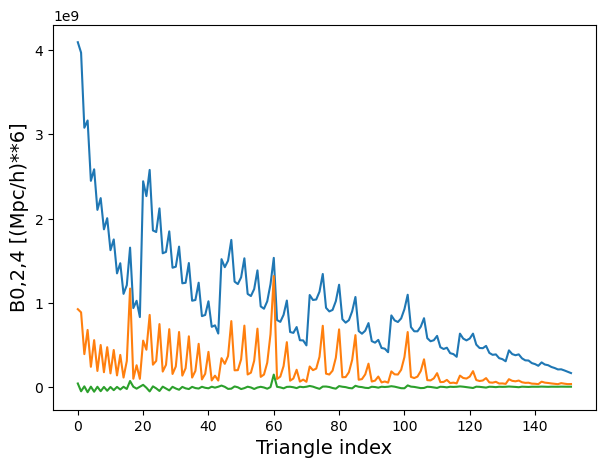

In [24]:
fig, axs = plt.subplots(figsize=(7,5))
axs.set_xlabel(r'Triangle index', fontsize =  14)
axs.set_ylabel(r'B0,2,4 [(Mpc/h)**6]', fontsize =  14)

# axs.plot(col2*col4*col6*B0/1, label=r'B0')

axs.plot(B0, label=r'B0')
axs.plot(B2, label=r'B0')
axs.plot(B4, label=r'B0')
# axs.plot(col2*col4*col6*B2/5, label=r'B0')

plt.show()

In [25]:
#extract equilateral and isosceles triangles
equilateral_n = []     
isosceles_n = []       

for i, (a, b, c) in enumerate(k1k2k3triplets):
    if a == b == c:
        equilateral_n.append(i)
    elif a == b or a == c or b == c:
        isosceles_n.append(i)
        
equilateral_n  = np.array(equilateral_n)    
isosceles_n = np.array(isosceles_n)

B0_equilateral=np.stack((equilateral_n, B0[equilateral_n]))
B0_isosceles=np.stack((isosceles_n, B0[isosceles_n]))


B2_equilateral=np.stack((equilateral_n, B2[equilateral_n]))
B2_isosceles=np.stack((isosceles_n, B2[isosceles_n]))

B4_equilateral=np.stack((equilateral_n, B4[equilateral_n]))
B4_isosceles=np.stack((isosceles_n, B4[isosceles_n]))

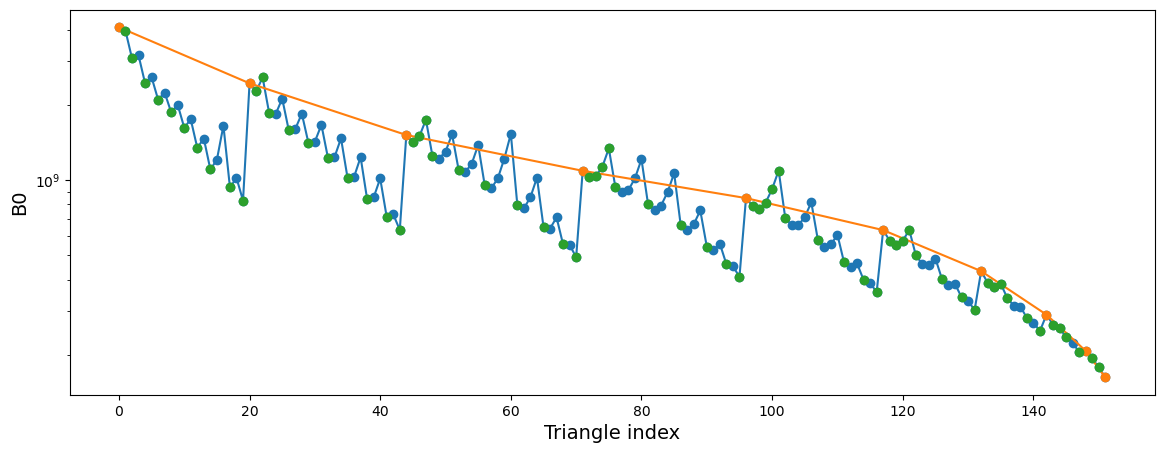

In [26]:
## check fig.2 of https://arxiv.org/pdf/1606.00439  CMASS NGC

fig, axs = plt.subplots(figsize=(14,5))
axs.set_xlabel(r'Triangle index', fontsize =  14)
axs.set_ylabel(r'B0', fontsize =  14)

x=np.arange(len(B0))
axs.semilogy(x,B0, 'o-')
axs.semilogy(B0_equilateral[0],B0_equilateral[1], 'o-')
axs.semilogy(B0_isosceles[0],B0_isosceles[1], 'o')

plt.show()

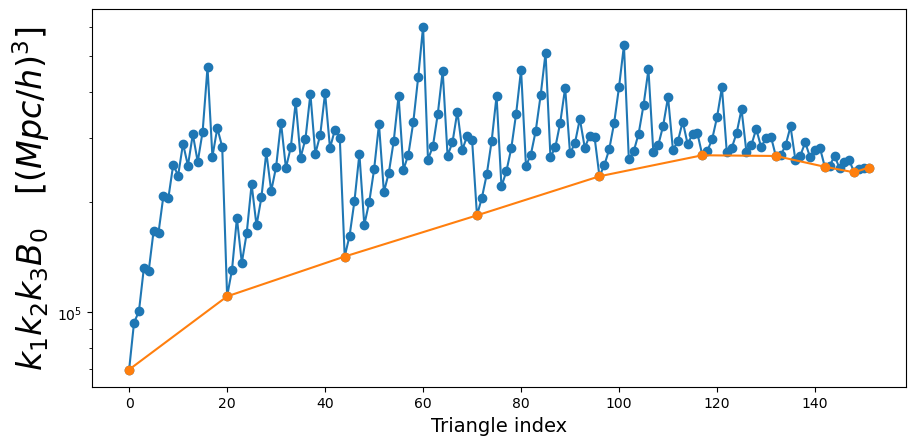

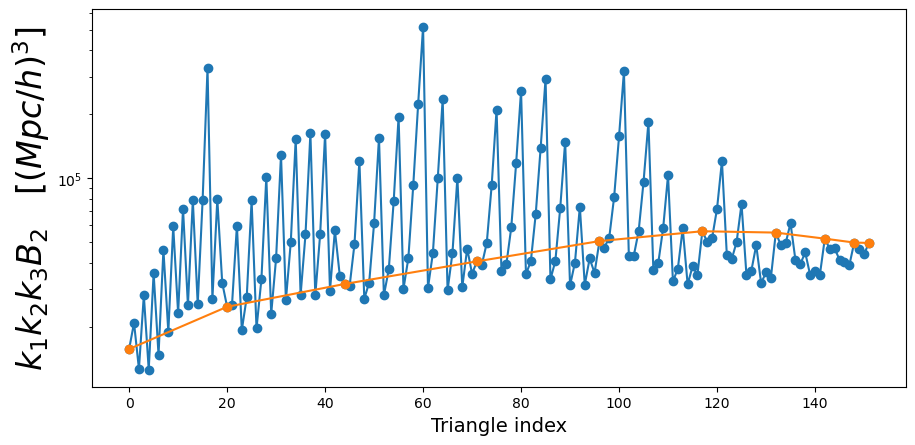

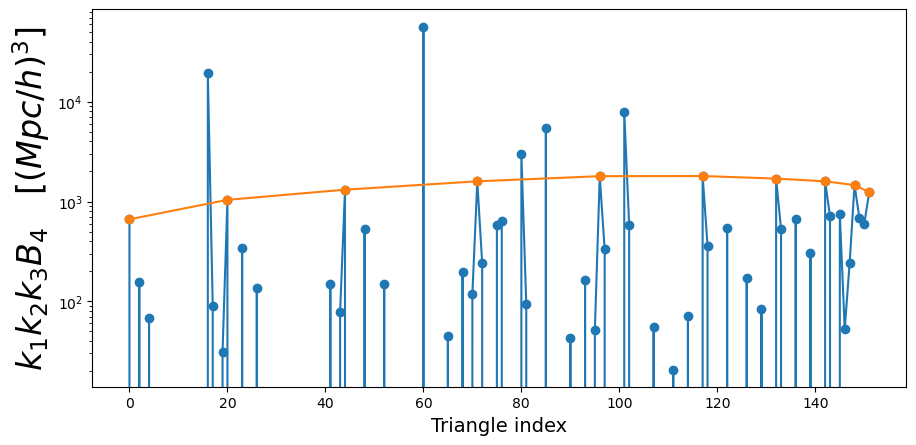

In [27]:

## check fig.2 of https://arxiv.org/pdf/2503.09714 (but her is a different cosmology)
rs=0.7
x=np.arange(len(B0))
en=equilateral_n

fig, axs = plt.subplots(figsize=(15*rs,7*rs))
axs.set_xlabel(r'Triangle index', fontsize =  14)
axs.set_ylabel(r'$k_1 k_2k_3 B_0 \quad [(Mpc/h)^3]$', fontsize =  24)
axs.semilogy(x,k1T*k2T*k3T*B0, 'o-')
axs.semilogy(B0_equilateral[0],k1T[en]*k2T[en]*k3T[en]*B0_equilateral[1], 'o-')
plt.show()

fig, axs = plt.subplots(figsize=(15*rs,7*rs))
axs.set_xlabel(r'Triangle index', fontsize =  14)
axs.set_ylabel(r'$k_1 k_2k_3 B_2 \quad [(Mpc/h)^3]$', fontsize =  24)
x=np.arange(len(B0))
axs.semilogy(x,k1T*k2T*k3T*B2, 'o-')
axs.semilogy(B2_equilateral[0],k1T[en]*k2T[en]*k3T[en]*B2_equilateral[1], 'o-')
plt.show()

fig, axs = plt.subplots(figsize=(15*rs,7*rs))
axs.set_xlabel(r'Triangle index', fontsize =  14)
axs.set_ylabel(r'$k_1 k_2k_3 B_4 \quad [(Mpc/h)^3]$', fontsize =  24)
axs.semilogy(x,k1T*k2T*k3T*B4, 'o-')
axs.semilogy(B4_equilateral[0],k1T[en]*k2T[en]*k3T[en]*B4_equilateral[1], 'o-')

plt.show()